##              `In the name of Allah, the most Gracious, the most Merciful` 

# Regression in Machine Learning

## What is Regression?

Regression is a **supervised learning** technique used to predict a
**continuous numerical value**.

Examples:

- House price
- Temperature
- Salary
- Sales
- Energy consumption

We have:

- `X` → input features
- `y` → target
- `ŷ` → predicted target

The goal is to learn a relationship:

$$
X \rightarrow y
$$

and use it to predict the target for new observations.

## Regression vs Classification

### Regression

Predicts a continuous numerical value.

Examples:

- Predict house price → `2,500,000`
- Predict temperature → `31.5°C`
- Predict salary → `15,000`

### Classification

Predicts a category/class.

Examples:

- Spam / Not Spam
- Cat / Dog
- Disease / No Disease

So:

$$
\boxed{\text{Regression} \rightarrow \text{Numbers}}
$$

$$
\boxed{\text{Classification} \rightarrow \text{Classes}}
$$

# 1. Linear Regression

A linear model predicts the target as a linear combination of the features.

For one feature:

$$
\hat{y} = wx + b
$$

For multiple features:

$$
\hat{y}
=
w_1x_1+w_2x_2+\cdots+w_px_p+b
$$

Where:

- $x_i$ → feature
- $w_i$ → coefficient / weight
- $b$ → intercept
- $\hat{y}$ → prediction

The coefficients determine how strongly each feature affects
the prediction.

# 2. Simple Linear Regression

Simple Linear Regression uses **one feature** to predict a continuous target.

Example:

Feature:
- house size

Target:
- house price

The model is:

$$
\hat{y}=wx+b
$$

Example:

$$
price = 5000(size)+100000
$$

### Interpretation

If the coefficient is:

$$
w=5000
$$

then increasing the house size by one unit increases the predicted
price by approximately 5000 units, assuming the model is appropriate.

### Advantage

- Very simple
- Easy to interpret

### Disadvantage

- Can only represent a straight-line relationship
- Cannot naturally capture complex curves

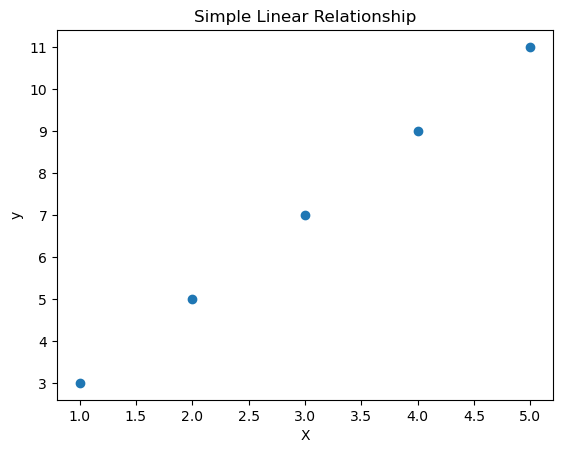

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# One feature
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)

# Target
y = np.array([3, 5, 7, 9, 11])

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Simple Linear Relationship")
plt.show()

# 3. Multiple Linear Regression

Multiple Linear Regression uses **multiple features** to predict one
continuous target.

Example: predicting house price using:

- size
- number of rooms
- age
- location

The model becomes:

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+w_4x_4+b
$$

Each coefficient represents the effect of its feature while the other
features are held constant.

### Important

Simple Linear Regression:

$$
\hat{y}=wx+b
$$

Multiple Linear Regression:

$$
\hat{y}=w_1x_1+\cdots+w_px_p+b
$$

Both are Linear Regression.

# 4. Ordinary Least Squares (OLS)

Ordinary Least Squares is the standard method used by
`LinearRegression` to find the coefficients of a linear model.

The idea is simple:

> Find the line that makes the prediction errors as small as possible.

For every observation:

$$
residual = y-\hat{y}
$$

The residual is the difference between:

- actual value
- predicted value

OLS minimizes the **sum of squared residuals**:

$$
\min_w ||Xw-y||_2^2
$$

In simple words:

1. Make predictions.
2. Calculate the errors.
3. Square the errors.
4. Add them together.
5. Find the coefficients that make this total as small as possible.

## Why do we square the errors?

Suppose we have:

$$
error_1=+5
$$

and

$$
error_2=-5
$$

If we simply add them:

$$
5+(-5)=0
$$

The errors cancel each other.

Instead, we square them:

$$
5^2+(-5)^2=25+25=50
$$

Now every error contributes positively.

Also, squaring makes large errors much more important.

In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [2.]
Intercept: 0.9999999999999982


# 5. Non-Negative Least Squares (NNLS)

Non-Negative Least Squares is a constrained version of Least Squares.

Normally, coefficients can be positive or negative:

$$
w_i \in (-\infty,\infty)
$$

With Non-Negative Least Squares:

$$
w_i \geq 0
$$

So the model is still trying to minimize the least-squares error,
but it is not allowed to use negative coefficients.

### Why?

This can be useful when coefficients represent naturally
non-negative quantities such as:

- frequencies
- prices
- counts
- physical quantities

In scikit-learn:

```python
LinearRegression(positive=True)

# 6. Ordinary Least Squares Complexity

This is NOT a new regression model.

It describes the computational cost of solving OLS.

If:

- `n_samples` = number of observations
- `n_features` = number of features

scikit-learn states that the least-squares solution uses
Singular Value Decomposition (SVD).

Assuming:

$$
n_{samples} \geq n_{features}
$$

the cost is approximately:

$$
O(n_{samples}n_{features}^2)
$$

### Meaning

As the number of samples or features increases,
the computation becomes more expensive.

You mainly need to understand the idea:

> More data/features → more computation.

# 7. Multicollinearity

Multicollinearity happens when features are highly correlated
with each other.

Example:

- house size in m²
- house size in ft²

These two features contain almost the same information.

Another example:

- age of a person
- year of birth

### Why is this a problem?

OLS coefficients can become unstable when features are highly correlated.

The model may have difficulty deciding:

> "Which feature should receive the importance?"

This can result in coefficients that are very sensitive to small changes
in the training data.

One solution is:

$$
\boxed{\text{Ridge Regression}}
$$

# 8. Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

The problem with OLS is that coefficients can become very large,
especially when features are correlated.

Ridge adds a penalty for large coefficients.

OLS minimizes:

$$
||Xw-y||_2^2
$$

Ridge minimizes:

$$
||Xw-y||_2^2+\alpha||w||_2^2
$$

The second term is the regularization penalty.

Because:

$$
||w||_2^2 = \sum_i w_i^2
$$

Ridge uses:

$$
\boxed{L2\ Regularization}
$$

## What does Ridge actually do?

Imagine OLS gives:

$$
w_1=20
$$

$$
w_2=-15
$$

Ridge says:

> "Try to keep the coefficients smaller."

So they may become something like:

$$
w_1=8
$$

$$
w_2=-6
$$

The exact values depend on the data and $\alpha$.

### Important

Ridge usually:

- shrinks coefficients toward zero
- does NOT usually make them exactly zero
- makes the model more robust to multicollinearity
- helps control overfitting

# 9. The Alpha Parameter

In Ridge:

```python
Ridge(alpha=...)

In [52]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.5)

ridge_model.fit(X, y)

print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)

Coefficients: [1.9047619]
Intercept: 1.2857142857142865


# 10. Ridge Solver

A solver is NOT another machine learning model.

A solver is simply the computational method used to find
the coefficients.

For example:

```python
Ridge(solver="auto")

## possible solvers include

- `lbfgs`

- `cholesky`

- `sparse_cg`

## Remember

``Solver = how the optimaization problem is computed``


# 11. Polynomial Regression

Sometimes the relationship between X and y is curved.

A straight line:

$$
y=wx+b
$$

may not be enough.

Polynomial Regression adds powers of the features.

For degree 2:

$$
\hat y=b+w_1x+w_2x^2
$$

For degree 3:

$$
\hat y=b+w_1x+w_2x^2+w_3x^3
$$

For degree n:

$$
\hat y=b+w_1x+w_2x^2+\cdots+w_nx^n
$$

## Why is Polynomial Regression still called a Linear Model?

This is an important concept.

Consider:

$$
y=b+w_1x+w_2x^2
$$

The relationship between `y` and `x` is curved.

But the model is still linear with respect to its parameters:

$$
b,\ w_1,\ w_2
$$

The coefficients are not multiplied together or placed inside
non-linear functions.

So Polynomial Regression can be implemented by transforming the
features:

$$
x \rightarrow [x,x^2,x^3,\ldots]
$$

and then applying a linear model.

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(X, y)

predictions = model.predict(X)

print(predictions)

[ 3.  5.  7.  9. 11.]


# Polynomial Degree and Overfitting

Increasing the polynomial degree makes the model more flexible.

For example:

Degree 1:

$$
y=b+w_1x
$$

Degree 2:

$$
y=b+w_1x+w_2x^2
$$

Degree 10:

$$
y=b+w_1x+\cdots+w_{10}x^{10}
$$

A very high degree can make the model follow the training data
too closely.

This is called:

$$
\boxed{\text{Overfitting}}
$$

So:

Low degree → may underfit

Very high degree → may overfit

We want a good balance.

# 12. Lasso Regression

Lasso is another regularized linear regression model.

Lasso uses:

$$
L1\ Regularization
$$

Its objective is:

$$
\min_w
\left(
||Xw-y||_2^2
+
\alpha\sum_i|w_i|
\right)
$$

Compare this with Ridge:

### Ridge

$$
MSE+\alpha\sum_iw_i^2
$$

### Lasso

$$
MSE+\alpha\sum_i|w_i|
$$

## Ridge vs Lasso

### Ridge

Uses:

$$
L2=\sum w_i^2
$$

Main effect:

> Shrinks coefficients toward zero.

Usually coefficients remain non-zero.

### Lasso

Uses:

$$
L1=\sum |w_i|
$$

Main effect:

> Can make some coefficients exactly zero.

Therefore Lasso can perform:

$$
\boxed{\text{Feature Selection}}
$$

If:

$$
w_3=0
$$

then feature 3 contributes nothing to the model.

### Easy memory trick

Ridge → shrink

Lasso → shrink + can remove features

In [54]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X, y)

print("Coefficients:", lasso_model.coef_)
print("Intercept:", lasso_model.intercept_)

Coefficients: [1.95]
Intercept: 1.1500000000000004


# 13. Support Vector Regression (SVR)

Support Vector Regression applies the Support Vector Machine idea
to regression.

Instead of predicting a class, SVR predicts a continuous value.

The key idea is the **epsilon-tube**.

We define a tolerance:

$$
\epsilon
$$

Small errors inside this tube are not penalized.

The model focuses on points outside the tube.

In simple words:

> "I don't need the prediction to be perfectly accurate.
> Small errors are acceptable."

This is called:

$$
\boxed{\epsilon\text{-insensitive loss}}
$$

## SVR and Non-Linear Relationships

SVR can use kernels to model non-linear relationships.

Examples:

- Linear kernel
- Polynomial kernel
- RBF kernel

The kernel allows the model to represent complex relationships
without explicitly creating all the transformed features ourselves.

So SVR can handle:

- linear relationships
- non-linear relationships

depending on the kernel.

In [55]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf")

svr_model.fit(X, y.ravel())

predictions = svr_model.predict(X)

print(predictions)

[5.4049138  5.53991362 7.         8.46008638 8.5950862 ]


# 14. Decision Tree Regression

Decision Tree Regression is NOT a linear model.

Instead of finding:

$$
y=wx+b
$$

the tree repeatedly splits the data using conditions.

Example:

        Is size < 100?
             /      \
           Yes       No
           /          \
      Is rooms < 3?   Prediction
        /    \
      ...     ...

The final nodes are called:

$$
\boxed{\text{Leaves}}
$$

Each leaf produces a numerical prediction.

## How does a Decision Tree make a prediction?

Imagine a house:

- Size = 150 m²
- Rooms = 4

The tree may ask:

1. Is size < 100?
2. No → go right.
3. Is rooms < 3?
4. No → go right.
5. Reach a leaf.

The leaf might predict:

$$
\hat y=2,000,000
$$

So the tree creates predictions by following a sequence
of decisions.

In [56]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_model.fit(X, y)

predictions = tree_model.predict(X)

print(predictions)

[ 3.  5.  7.  9. 11.]


# Decision Tree Regression

### Advantages

- Easy to understand
- Can model non-linear relationships
- Does not require a linear relationship between features and target
- Can capture interactions between features

### Disadvantage

Decision trees can easily overfit.

A very deep tree can memorize the training data.

Therefore, parameters such as:

```python
max_depth


---

# 15. Random Forest Regression

Random Forest is an ensemble model.

Instead of using one Decision Tree:

$$
Tree_1
$$

we build many trees:

$$
Tree_1,Tree_2,\ldots,Tree_n
$$

Each tree produces a prediction.

For regression, the predictions are generally averaged:

$$
\hat y =
\frac{1}{n}
\sum_{i=1}^{n}\hat y_i
$$

Example:

Tree 1 → 1.8M

Tree 2 → 2.0M

Tree 3 → 1.9M

Tree 4 → 2.1M

Average → approximately 1.95M

## Why use many trees?

A single Decision Tree can have high variance and overfit.

Random Forest combines many different trees.

This usually makes the model:

- more stable
- more robust
- less likely to overfit than one unrestricted tree

Random Forest is an example of:

$$
\boxed{\text{Ensemble Learning}}
$$

It uses the idea of:

$$
\boxed{\text{Bagging}}
$$

which means combining models trained on different samples
of the data.

In [57]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X, y)

predictions = forest_model.predict(X)

print(predictions)

[ 3.74  4.64  6.64  8.56 10.1 ]


# 16. Regression Evaluation Metrics

A model is not useful just because it can make predictions.

We need to measure:

> How good are the predictions?

Common regression metrics:

1. MAE
2. MSE
3. RMSE
4. R² Score
5. Huber Loss

# 16. Regression Evaluation Metrics

A model is not useful just because it can make predictions.

We need to measure:

> How good are the predictions?

Common regression metrics:

1. MAE
2. MSE
3. RMSE
4. R² Score
5. Huber Loss

In [58]:
from sklearn.metrics import mean_absolute_error

y_true = [100, 200, 300]
y_pred = [90, 220, 290]

mae = mean_absolute_error(y_true, y_pred)

print("MAE:", mae)

MAE: 13.333333333333334


# Mean Squared Error (MSE)

MSE calculates the average squared prediction error.

$$
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
$$

The important thing is the square.

A large error becomes much larger after squaring.

For example:

$$
10^2=100
$$

but:

$$
100^2=10000
$$

Therefore MSE is very sensitive to large errors and outliers.

### Important

Lower MSE = better.

In [59]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, y_pred)

print("MSE:", mse)

MSE: 200.0


# Root Mean Squared Error (RMSE)

RMSE is simply the square root of MSE.

$$
RMSE=\sqrt{MSE}
$$

Why?

Because MSE is expressed in squared units.

If the target is measured in:

$$
\text{EGP}
$$

MSE is in:

$$
EGP^2
$$

Taking the square root returns the metric to the original unit:

$$
EGP
$$

Therefore RMSE is often easier to interpret than MSE.

### Important

Lower RMSE = better.

In [60]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_true, y_pred)

print("RMSE:", rmse)

RMSE: 14.142135623730951


# R² Score

R² is called the coefficient of determination.

It measures how well the model explains the variation in the target.

A perfect model has:

$$
R^2=1
$$

A value around:

$$
R^2=0
$$

means the model is not explaining the variation better than
a simple mean-based baseline.

Important:

R² can be negative in some cases.

So do NOT memorize:

> "R² is always between 0 and 1."

The best possible value is 1, but there is no strict lower bound.

### Higher R² is generally better.

In [61]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)

print("R²:", r2)

R²: 0.97


# Huber Loss

Huber Loss combines ideas from MSE and MAE.

For small errors, it behaves similarly to squared error.

For large errors, it behaves more like absolute error.

Why?

Because MSE is very sensitive to outliers.

Huber Loss tries to get:

- the smooth behavior of MSE for small errors
- the robustness of MAE for large errors

Therefore Huber Loss is useful when we want
some protection against outliers.

# 17. Regression Model Comparison

| Model | Main Idea |
|------|-----------|
| Linear Regression | Fit a linear relationship |
| Ridge | Linear Regression + L2 regularization |
| Lasso | Linear Regression + L1 regularization |
| Polynomial Regression | Transform features with powers |
| SVR | Fit an epsilon-tube around predictions |
| Decision Tree | Split data using decision rules |
| Random Forest | Combine many Decision Trees |

### Regularization

Ridge → L2

Lasso → L1

### Ensemble

Random Forest → many trees

### Tree-based

Decision Tree

Random Forest

### SVM-based

SVR

# 18. Important Distinction

Not everything in this notebook is a "Linear Model".

### Linear Models

- Linear Regression
- OLS
- Ridge
- Lasso
- Polynomial Regression after feature transformation

### Other Regression Models

- SVR
- Decision Tree Regression
- Random Forest Regression

### Evaluation Metrics

- MAE
- MSE
- RMSE
- R²
- Huber Loss

Metrics do NOT make predictions.

They evaluate the predictions made by models.

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load data
df = pd.read_csv("Housing.csv")

# Feature
X = df[["lotsize"]]

# Target
y = df["price"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 17465.64416385439
MSE: 543921224.5593488
RMSE: 23322.118783664337
R²: 0.18583856088525574


# 19. What Happens in the Workflow?

The complete Machine Learning workflow here is:

### Step 1 — Load data

```python
df = pd.read_csv(...)

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
X = df[["lotsize"]]
y = df["price"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
model = LinearRegression()

In [67]:
model.fit(X_train, y_train)

LinearRegression()

In [68]:
y_pred = model.predict(X_test)


---


# 20. What Should I Remember?

## Linear Regression

$$
\hat y = w_1x_1+\cdots+w_px_p+b
$$

## OLS

Minimize:

$$
\sum(y-\hat y)^2
$$

## Ridge

OLS + L2 penalty:

$$
MSE+\alpha\sum w_i^2
$$

Large $\alpha$ → more shrinkage.

## Lasso

OLS + L1 penalty:

$$
MSE+\alpha\sum|w_i|
$$

Can make coefficients exactly zero.

## Polynomial Regression

Add:

$$
x^2,x^3,\ldots
$$

to capture curved relationships.

## SVR

Uses an $\epsilon$-tube and can use kernels.

## Decision Tree

Uses decision rules and splits the data.

## Random Forest

Combines many Decision Trees.

## Metrics

MAE → average absolute error

MSE → squared error

RMSE → square root of MSE

R² → goodness of fit / explained variation

Huber → more robust to large errors/outliers

# 21. The Mental Picture

Imagine we want to predict house prices.

### Linear Regression

"Let me draw the best straight line."

### Ridge

"Let me draw a good line, but don't let the coefficients become huge."

### Lasso

"Let me draw a good line and remove unnecessary features if possible."

### Polynomial Regression

"A straight line isn't enough. Let me create curved relationships."

### SVR

"Small errors are okay. I'll focus on points outside my epsilon tube."

### Decision Tree

"I'll ask a sequence of questions and divide the data."

### Random Forest

"Instead of trusting one tree, I'll ask many trees and average them."

### Metrics

"Now let's measure how good the predictions actually are."